##**PROGETTO: Riconoscimento di animali per auto a guida autonoma**

## Dichiarazione di intenti e Architettura

Il progetto richiede di realizzare un sistema di riconoscimento basato su immagini,
finalizzato a distinguere animali e veicoli nello scenario della guida autonoma e
della sicurezza stradale. Si tratta di un problema di **classificazione multi-classe
di immagini**, affrontato tramite una rete neurale convoluzionale (CNN).

Il dataset utilizzato per l'addestramento è **CIFAR-10**, composto da 60.000 immagini
a colori di dimensione 32×32 pixel, suddivise in 10 classi. Analizzando la
documentazione del dataset e ispezionando visivamente le immagini, le 10 classi
originali sono riconducibili a tre raggruppamenti funzionali allo scenario del
progetto: animali, veicoli da strada e veicoli non da strada (come aeroplani e navi).

Coerentemente con la richiesta progettuale, ho impostato il problema come
una **classificazione a 3 classi**, ottenute aggregando le 10 categorie originali:

1. **VEICOLI DA STRADA** — unione delle label *automobile* e *truck*
2. **ANIMALI** — unione delle label *bird, cat, deer, dog, frog, horse*
3. **VEICOLI NON DA STRADA** — unione delle label rimanenti (*airplane, ship*)

Le motivazioni dettagliate di questa scelta — in particolare la decisione di
mantenere tre classi anziché ridurre il problema a una classificazione binaria,
e le relative implicazioni sul bilanciamento del dataset — le discuto nella
sezione "Decisione architetturale".

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, GlobalAveragePooling2D, Dense, MaxPooling2D, Input
from tensorflow.keras.datasets import cifar10
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
percorso = '/content/drive/MyDrive/Progetti Master/files e dataframe/'

In [ ]:
#Imposto i seed, da runnare ogni volta prima del fit
tf.keras.utils.set_random_seed(42)

In [4]:

#funzione salva array in drive
def save_in_drive(path:str,x_train,x_test,y_train,y_test):
  np.save(path+'x_train.npy', x_train)
  np.save(path+'x_test.npy', x_test)
  np.save(path+'y_train.npy', y_train)
  np.save(path+'y_test.npy', y_test)

#funziona carica array da drive
def load_from_drive(path:str):
  x_train = np.load(path+'x_train.npy')
  x_test = np.load(path+'x_test.npy')
  y_train = np.load(path+'y_train.npy')
  y_test = np.load(path+'y_test.npy')

  return (x_train,y_train), (x_test,y_test)

#funzione di caricamento dati generale (carica e salva in drive)

def load_data_cifar(path:str):
  #se il path delle cartelle esiste
  if os.path.exists(path) and len(os.listdir(path)) > 0:
    #carico con la funzione load_from_drive
    (x_train,y_train), (x_test,y_test)= load_from_drive(path)
  #se il path non esiste oppure esiste ma senza file dentro creo cartella se non esiste e carico dati e file
  else:
    #quindi creo la cartella Progetti Master e dentro la cartella progetti master creo la cartella files e dataframe ed entro dentro

    os.makedirs(path, exist_ok = True)
    (x_train, y_train), (x_test, y_test) = cifar10.load_data() #carico i dati
    save_in_drive(path,x_train,x_test,y_train,y_test) #salvo i dati

  return (x_train, y_train), (x_test, y_test)

In [5]:
percorso = '/content/drive/MyDrive/Progetti Master/files e dataframe/' #definisco il percorso del drive
(x_train, y_train), (x_test, y_test) = load_data_cifar(percorso)

In [6]:
#shapes:
x_train.shape #(50000, 32, 32, 3)
y_train.shape #(50000, 1)
x_test.shape #(10000, 32, 32, 3)
y_test.shape #(10000, 1)

#valore min x_train, x_test:0
#valore max x_train, x_test: 255

#NORMALIZZAZIONE
x_train = (x_train / 255.0).astype('float32')
x_test  = (x_test  / 255.0).astype('float32')

In [8]:
np.unique(y_train) #10 classi, da 0 a 9

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [7]:
#definisco il dizionario delle label

label_mapping = {

                 0: ('airplane','VEICOLI-NO-STRADA'),
                 1: ('automobile','VEICOLI DA STRADA'),
                 2: ('bird','ANIMALI'),
                 3: ('cat','ANIMALI'),
                 4: ('deer','ANIMALI'),
                 5: ('dog','ANIMALI'),
                 6: ('frog','ANIMALI'),
                 7: ('horse','ANIMALI'),
                 8: ('ship','VEICOLI-NO-STRADA'),
                 9: ('truck','VEICOLI DA STRADA'),

}

In [10]:
np.unique(y_train,return_counts=True) #10 classi, da 0 a 9

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]))

In [8]:
#PASSO A 3 CLASSI SIA SUL TRAIN CHE SUL TEST TARGET
y = y_train.flatten()
y_train_3classi = np.array([label_mapping[n][1] for n in y])

y = y_test.flatten()
y_test_3classi = np.array([label_mapping[n][1] for n in y])

In [12]:
np.unique(y_train_3classi,return_counts=True) #3 classi

#set di dati sbilanciati. Quindi cerco di massimizzare la F1-score per gestire un buon bilanciamento tra precision (che è svantaggiata nella classificazione degli animali) e recall (che è svantaggiata nella classificazione
#dei veicoli di strada)

(array(['ANIMALI', 'VEICOLI DA STRADA', 'VEICOLI-NO-STRADA'], dtype='<U17'),
 array([30000, 10000, 10000]))

In [13]:
np.unique(y_test_3classi,return_counts=True) #3 classi

(array(['ANIMALI', 'VEICOLI DA STRADA', 'VEICOLI-NO-STRADA'], dtype='<U17'),
 array([6000, 2000, 2000]))

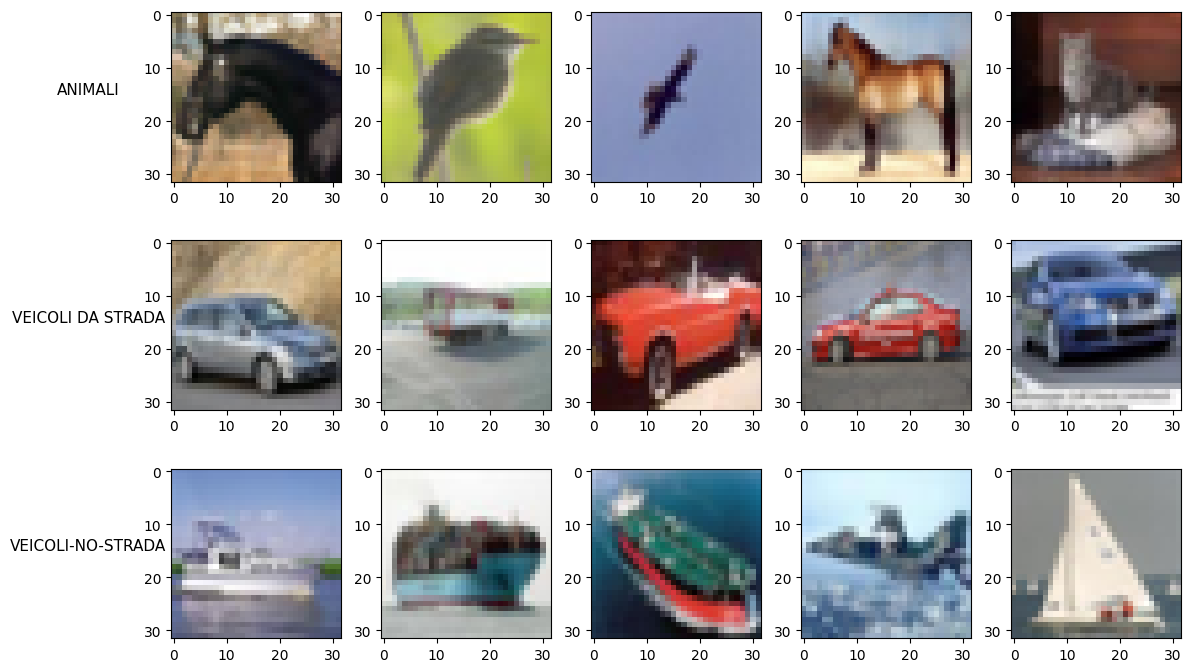

In [14]:
#Faccio un pò di visual inspection per capire che tipo di immagini trovo

classi = ['ANIMALI', 'VEICOLI DA STRADA', 'VEICOLI-NO-STRADA']
n_per_classe = 5

fig, axes = plt.subplots(3, 5, figsize=(12, 7))

for r, nome_classe in enumerate(classi):
    # trovo gli indici di tutte le immagini di questa classe
    #         (usa y_train_3classi e np.where)
    indici_classe = np.where(y_train_3classi == nome_classe)[0]

    # Pesco 5 indici casuali
    scelti = np.random.choice(indici_classe, size=5, replace=False)

    for c, idx in enumerate(scelti):

        axes[r][c].imshow(x_train[idx])
        #axes[r][c].axis('off')
        if c == 0:
          axes[r][c].set_ylabel(nome_classe, fontsize=11, rotation=0, labelpad=40)

plt.tight_layout()
plt.show()

## Decisione architetturale

Ho deciso di impostare il problema come una classificazione a 3 classi, anziché
semplificarlo a due classi (animali contro veicoli da strada) buttando via le
categorie che non c'entrano con la strada. La tentazione di ridurlo a un problema
binario c'era, ma ho preferito tenere tre classi per due motivi.

Il primo è che scartare aeroplani e navi avrebbe significato eliminare circa il 33%
del dataset, cioè 20.000 immagini etichettate: una perdita di dati notevole e, a
mio avviso, ingiustificata. Il secondo motivo, più legato al senso del progetto, è
che un sistema di monitoraggio reale non vede soltanto animali e automobili. Deve
anche saper riconoscere ciò che non deve far scattare un allarme, invece di essere
costretto a etichettare qualsiasi cosa come animale o veicolo. In questo senso la
classe "veicoli non da strada" è un primo esempio di categoria "da ignorare" che
il modello impara a tenere separata.

Questa scelta ha però un prezzo: le tre classi sono
sbilanciate (nel training ho 30.000 animali contro 10.000 veicoli da strada e
10.000 non da strada, un rapporto di 3 a 1 a 1). Lo sbilanciamento lo gestirò in
fase di valutazione, guardando soprattutto il macro-F1 e il recall sulle classi
meno numerose, piuttosto che la sola accuratezza. L'accuratezza da sola, qui,
ingannerebbe: un modello che dicesse sempre "animali" arriverebbe già intorno al
60% pur senza aver imparato niente.

Da tutto questo discende l'architettura: trattandosi di un problema a tre classi,
l'ultimo strato della rete è un layer denso con 3 neuroni e attivazione softmax.
Le etichette le ho codificate in one-hot, e di conseguenza la funzione di perdita
è la categorical_crossentropy.

Istanziamento Modello

Modello con data augmentation

In [43]:
#data augmentation
#proviamo a vedere se le performance migliorano con data augmentation

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

**MODELLO STANDARD**

In [64]:
#creo la rete neurale standard
model = Sequential([

                    #input (32,32,3) - output (32,32,64)
                   Conv2D(
                          input_shape = (32,32,3),
                          filters= 64,
                          padding = 'same',
                          kernel_size = (3,3),
                          activation = 'relu'),

                    #input (32,32,64) - output (16,16,64)
                   MaxPooling2D(pool_size=(2,2)),

                    #input (16,16,64) - output (16,16,128)
                   Conv2D(
                          filters= 128,
                          padding = 'same',
                          kernel_size = (3,3),
                          activation = 'relu'),

                     #input (16,16,128) - output (8,8,128)
                    MaxPooling2D(pool_size=(2,2)),

                     #input (8, 8, 128) - output (128,)
                    GlobalAveragePooling2D(), #più efficace di Flatten, toglie complessità alla rete e aiuta contro l'overfitting

                    Dense(64, activation='relu'),

                    Dense(3, activation='softmax'),


]
)


model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,099 (328.51 KB)

 Trainable params: 84,099 (328.51 KB)

 Non-trainable params: 0 (0.00 B)

Modello con cui ho ricevuto i migliori risultati. Early stopping: 22 come miglior epoca.

**MODELLO CON DATA AUGMENTATION**

In [51]:
#creo la rete neurale con data augmentation
model = Sequential([

                    Input(shape=(32,32,3)),
                    data_augmentation,
                    #input (32,32,3) - output (32,32,64)
                    Conv2D(

                            filters= 64,
                            padding = 'same',
                            kernel_size = (3,3),
                            activation = 'relu'),

                      #input (32,32,64) - output (16,16,64)
                    MaxPooling2D(pool_size=(2,2)),

                      #input (16,16,64) - output (16,16,128)
                    Conv2D(
                            filters= 128,
                            padding = 'same',
                            kernel_size = (3,3),
                            activation = 'relu'),

                      #input (16,16,128) - output (8,8,128)
                      MaxPooling2D(pool_size=(2,2)),

                      #input (8, 8, 128) - output (128,)
                      GlobalAveragePooling2D(), #più efficace di Flatten, toglie complessità alla rete e aiuta contro l'overfitting

                      Dense(64, activation='relu'),

                      Dense(3, activation='softmax'),


]
)


model.summary()



Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,099 (328.51 KB)

 Trainable params: 84,099 (328.51 KB)

 Non-trainable params: 0 (0.00 B)

Ho sperimentato la data augmentation come possibile miglioria. I risultati sono peggiorati: il modello, che non mostrava overfitting, non beneficiava della regolarizzazione introdotta, mentre la risoluzione molto bassa (32×32) rende le trasformazioni geometriche più dannose che utili. Ho quindi mantenuto il modello senza augmentation per i risultati finali, pur riportando il codice per il modello con data augmentation per prove future. Consiglio di utilizzare una patience diversa sull'early stopping per perché il modello si è arenato dopo 10 epoche, con epoca migliore la 6.
In generale però il modello base non presentava overfitting, quindi non necessitava della regolarizzazione che l'augmentation fornisce. Ho quindi adottato il modello senza augmentation (ottimo all'epoca 27)

Training

In [65]:
#callback

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True, # riporta ai pesi migliori quando si ferma
    verbose=1
)

In [66]:
#compilazione

model.compile(optimizer='adam',
              loss = 'categorical_crossentropy',
              metrics =['accuracy'])

#encoding
#conversione array stringhe 3 classi --> array numerico 3 classi
le = LabelEncoder()
y_train_int = le.fit_transform(y_train_3classi)
y_test_int = le.transform(y_test_3classi)
#da interi a one-hot
y_train_onehot = to_categorical(y_train_int, num_classes=3)   # (50000, 3)
y_test_onehot  = to_categorical(y_test_int,  num_classes=3)   # (10000, 3)

#fit
history = model.fit(x_train,y_train_onehot,batch_size=32,epochs = 50, verbose = True, validation_split = 0.2, callbacks = [early_stop])

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7675 - loss: 0.5743 - val_accuracy: 0.8193 - val_loss: 0.4580
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8252 - loss: 0.4490 - val_accuracy: 0.8402 - val_loss: 0.4149
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8487 - loss: 0.3973 - val_accuracy: 0.8578 - val_loss: 0.3748
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8623 - loss: 0.3634 - val_accuracy: 0.8706 - val_loss: 0.3460
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8713 - loss: 0.3400 - val_accuracy: 0.8813 - val_loss: 0.3220
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8795 - loss: 0.3213 - val_accuracy: 0.8876 - val_loss: 0.3070
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8859 - loss: 0.3054 - val_accuracy: 0.8906 - val_loss: 0.2939
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8926 - loss: 0.2905 - 

In [67]:
y_pred = np.argmax(model.predict(x_test), axis = 1)
print(classification_report(
          y_test_int, #verità
          y_pred,     #predizioni
          target_names =le.classes_ # i nomi delle classi
      )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
                   precision    recall  f1-score   support

          ANIMALI       0.96      0.94      0.95      6000
VEICOLI DA STRADA       0.88      0.92      0.90      2000
VEICOLI-NO-STRADA       0.83      0.85      0.84      2000

         accuracy                           0.92     10000
        macro avg       0.89      0.90      0.90     10000
     weighted avg       0.92      0.92      0.92     10000



Confusion Matrix

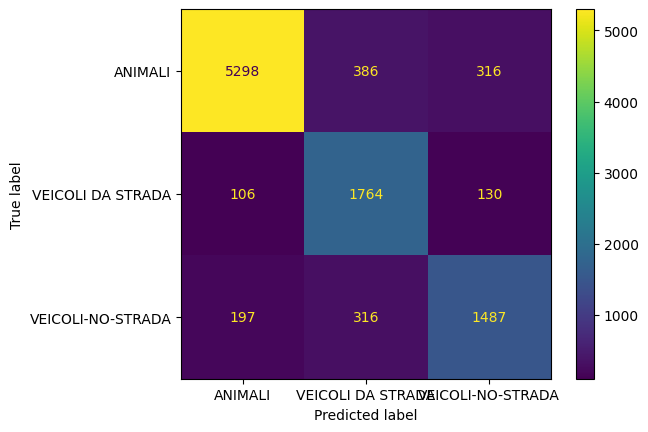

In [56]:
#Confusion Matrix
#con early stopping + data augmentation
cm = confusion_matrix(y_test_int, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot()

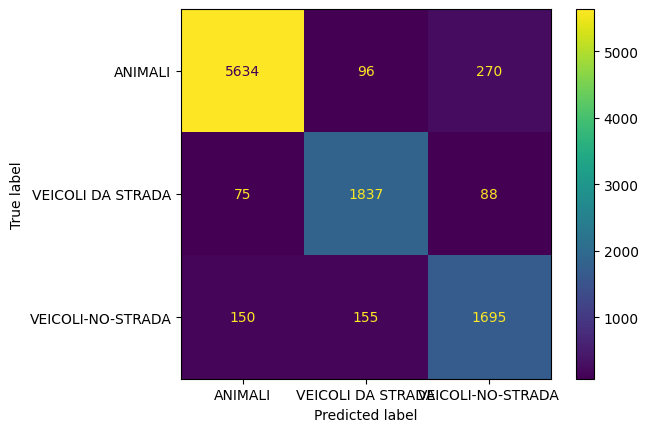

In [68]:
#Confusion Matrix
#con early stopping
cm = confusion_matrix(y_test_int, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot()

**ANALISI DEI RISULTATI e VISUALIZZAZIONI**

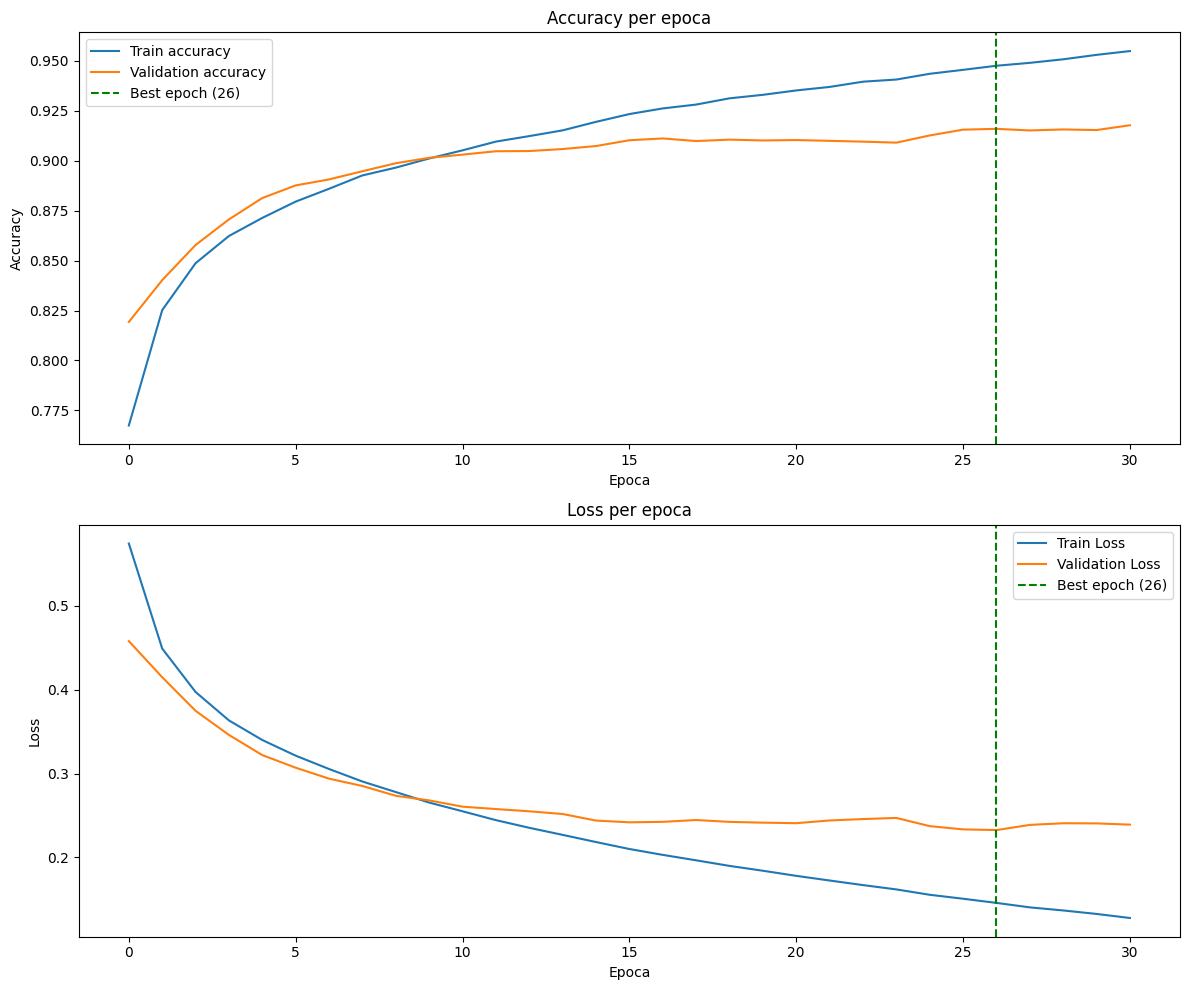

In [86]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']

# epoca migliore
best_epoch = np.argmin(history.history['val_loss'])

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- GRAFICO 1: le due accuracy ---
axes[0].plot(acc,     label='Train accuracy')
axes[0].plot(val_acc, label='Validation accuracy')
axes[0].axvline(best_epoch, color='green', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[0].set_title('Accuracy per epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# --- GRAFICO 2: le due loss ---
axes[1].plot(loss,     label='Train Loss')
axes[1].plot(val_loss, label='Validation Loss')
axes[1].axvline(best_epoch, color='green', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[1].set_title('Loss per epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

Totale immagini misclassificate: 834 su 10000


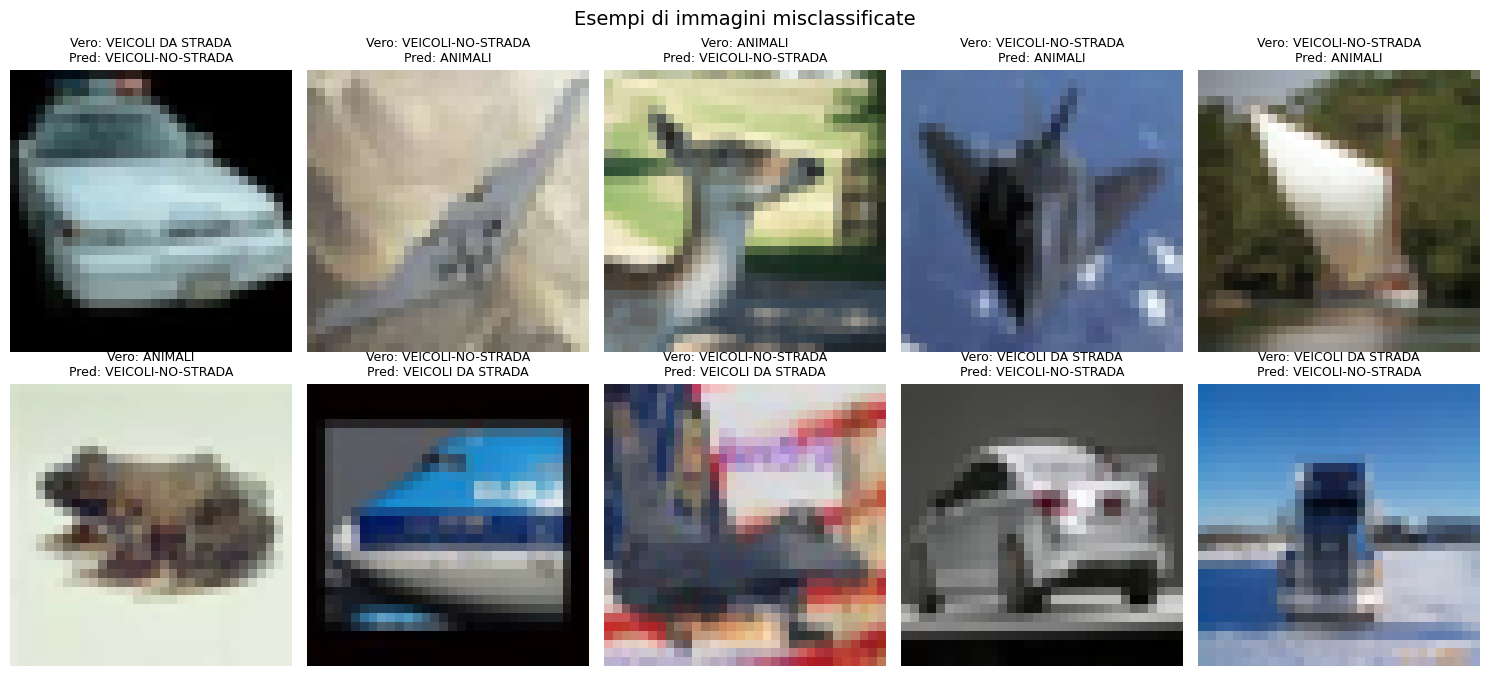

In [88]:
# Esame delle immagini misclassificate
#  predizioni (y_pred) ed etichette vere (y_test_int)
# per trovare gli errori e visualizzarli.

# trovo gli indici dove il modello ha sbagliato
errori = np.where(y_pred != y_test_int)[0]
print(f"Totale immagini misclassificate: {len(errori)} su {len(y_test_int)}")

# ne mostro 10 a caso, con etichetta vera e predetta
np.random.seed(42)
campione = np.random.choice(errori, size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for ax, idx in zip(axes.flat, campione):
    ax.imshow(x_test[idx])
    vero     = le.classes_[y_test_int[idx]]   # nome classe vera
    predetto = le.classes_[y_pred[idx]]        # nome classe predetta
    ax.set_title(f"Vero: {vero}\nPred: {predetto}", fontsize=9)
    ax.axis('off')

plt.suptitle("Esempi di immagini misclassificate", fontsize=14)
plt.tight_layout()
plt.show()

### Esame delle immagini misclassificate

Guardando una per una le immagini su cui il modello ha sbagliato, mi sono accorto
che gli errori non sono affatto casuali: quasi sempre c'è un motivo visivo preciso,
e in parecchi casi anche io, guardando l'immagine a 32×32 pixel, avrei avuto qualche
dubbio. Questo è già di per sé rassicurante, perché vuol dire che il modello sbaglia
"sensatamente".

Mi sono saltate all'occhio soprattutto tre situazioni ricorrenti.

La prima, e la più interessante, è che il modello sembra farsi condizionare dallo
sfondo. Diversi aerei e navi che si trovano su uno sfondo naturale — il cielo, la
vegetazione, l'acqua — finiscono classificati come animali. È come se il contesto
intorno al soggetto pesasse quasi quanto il soggetto stesso: la nave circondata da
alberi e l'aereo nel cielo, per esempio, vengono entrambi predetti come "ANIMALI".

La seconda è la confusione tra i due tipi di veicoli, che del resto avevo già
previsto guardando la confusion matrix. Qui il motivo si vede a occhio:
un'automobile chiara ripresa di lato ha lo stesso profilo e le stesse superfici
metalliche di una nave, e viceversa. Sono esattamente i casi della coppia
VEICOLI DA STRADA ↔ NON DA STRADA.

La terza è più banale ma va detta: alcune immagini sono semplicemente ambigue di
loro. Soggetti sgranati, inquadrati a metà o in pose strane, dove l'errore è
comprensibile e a volte la classe predetta dal modello è perfino plausibile.

## Analisi dei risultati

Per questa analisi mi baso sul modello che ha dato i risultati migliori, cioè
l'architettura standard con EarlyStopping, che si è fermato individuando come
ottimale la 27ª epoca (poi ripristinata grazie a restore_best_weights).

Nel complesso il modello distingue bene le tre classi: la diagonale della confusion
matrix è nettamente dominante e tutte le categorie superano lo 0.80 di F1-score, con
un'accuratezza globale intorno al 91%. È un risultato che mi dice che il modello ha
imparato davvero a riconoscere le immagini, e non si limita a sfruttare lo
sbilanciamento a suo favore: un classificatore "pigro" che dicesse sempre "animali"
si fermerebbe intorno al 60%, quindi siamo ben oltre.

Guardando dove sbaglia, ho notato due schemi che si ripetono.

Il primo è che la classe ANIMALI funziona un po' da "calamita": una parte dei veicoli,
sia da strada sia non da strada, finisce classificata come animale. Ha senso, se penso
allo sbilanciamento del dataset: gli animali sono il 60% degli esempi, e quando il
modello è incerto tende a buttarsi sulla classe più frequente, perché statisticamente
gli conviene. Il risultato è che a soffrirne è soprattutto il recall delle due classi
di veicoli, più che la precision degli animali, che resta alta.

Il secondo schema è la confusione reciproca tra veicoli da strada e veicoli non da
strada: si contano 155 casi di "non da strada" scambiati per "da strada", più i casi
opposti. Anche qui il motivo si capisce: le due categorie condividono caratteristiche
di base — superfici metalliche, forme squadrate, geometrie regolari — che a 32×32
pixel diventano davvero difficili da separare.

La coppia più critica, alla fine, è quella tra VEICOLI NON DA STRADA e ANIMALI. È il
punto dove si sommano due cose: lo sbilanciamento di cui sopra e il fatto che la classe
"veicoli non da strada" è poco omogenea al suo interno (aerei su sfondo di cielo, navi
su sfondo d'acqua, a volte visivamente vicini a soggetti naturali). Non a caso è la
classe con il recall più basso, ed è lì che vedo i margini di miglioramento maggiori.

A questo si lega un'osservazione che emerge guardando le immagini sbagliate: il modello
tende a confondersi quando lo sfondo è "tipico" di un'altra classe — un aereo nel cielo
o una nave sull'acqua finiscono tra gli animali. È il segno che non ha ancora imparato
a isolare bene il soggetto dal contesto in cui si trova.

## Risultato finale e analisi critica

Il modello finale è una CNN sequenziale piuttosto semplice: due blocchi convoluzionali
(Conv2D seguito da MaxPooling, con 64 e 128 filtri), poi un GlobalAveragePooling2D e
infine un classificatore denso con softmax a 3 neuroni. Ho scelto il
GlobalAveragePooling al posto del più classico Flatten proprio per tenere basso il
numero di parametri e ridurre il rischio di overfitting: in tutto la rete conta circa
84.000 parametri, una dimensione che ho voluto contenuta perché, viste le immagini a
32×32, una rete più grande sarebbe stata sproporzionata.

Sulla scelta delle metriche ci ho ragionato parecchio. Trattandosi di classi sbilanciate (30.000 / 10.000 / 10.000), l'accuratezza
globale da sola non mi convinceva: tende a dare un quadro troppo ottimistico, perché
viene trainata dalla classe più numerosa. Ho quindi guardato le metriche classe per
classe (precision, recall e F1) e, come numero di sintesi, il macro-F1, che dà lo stesso
peso a tutte e tre le classi. In questo modo le ottime prestazioni sugli animali non
nascondono le difficoltà sulle classi meno numerose, che poi sono quelle che contano di
più nello scenario della sicurezza stradale.

Quanto ai risultati, il macro-F1 è buono e tutte le classi stanno sopra 0.80 di F1. Le
curve di addestramento raccontano una storia sana: train e validation vanno appaiate
fino a circa l'epoca 10, poi si aprono leggermente — la train loss continua a scendere
mentre la validation si stabilizza. È un overfitting lieve e tutto sommato fisiologico,
che l'EarlyStopping ha gestito bene fermandosi al punto giusto.

Detto questo, il modello ha dei limiti che è giusto riconoscere:

- **Risoluzione.** A 32×32 pixel certe distinzioni sono difficili a prescindere, e
  questo mette un tetto naturale a quanto si può ottenere.
- **Sbilanciamento.** L'ho gestito in fase di valutazione, ma non durante
  l'addestramento: il modello mantiene quindi la tendenza a sovra-predire gli animali.
- **Classe "veicoli non da strada" poco omogenea.** Aerei e navi sono molto diversi
  tra loro, e questo rende la categoria meno coesa e più difficile da imparare.

E proprio da questi limiti partirebbero le cose che si potrebbero provare:

- **Class weights**, per pesare di più gli errori sulle classi minoritarie durante
  l'addestramento e affrontare lo sbilanciamento alla radice, non solo in valutazione come ho fatto scegliendo semplicemente le metriche che ritengo corrette.
- **Data augmentation calibrata.** Il mio esperimento l'ha peggiorata, ma credo per come
  l'ho impostata: con una patience più alta (così da non tagliare un addestramento reso
  più lento) e trasformazioni più leggere potrebbe aiutare, soprattutto contro
  l'overfitting che ho osservato.
- **Una rete più profonda con Dropout**, per imparare caratteristiche più fini che
  distinguano meglio i due tipi di veicoli, tenendo però sotto controllo l'overfitting
  che ne deriverebbe.